re-doing my setup for the ANTARES filter system since the pitt-google setup is having issues. i'm testing a filter using the [structure of a filter](https://nsf-noirlab.gitlab.io/csdc/antares/devkit/learn/structure-of-a-filter/) example, the [anomaly transient dmdt filter](https://nsf-noirlab.gitlab.io/csdc/antares/devkit/reference/filters/malanchev_anomaly_transient_dmdt/), and the [editing real loci example](https://nsf-noirlab.gitlab.io/csdc/antares/devkit/learn/testing-filters/#building-test-cases) as a baseline for it

In [21]:
from antares_devkit.models import BaseFilter
from antares_devkit.models import DevKitLocus
from antares_client import search
import numpy as np

In [67]:
client_locus = search.get_by_id("ANT2020alvpw") # 2
locus_dict = client_locus.to_devkit()
locus_dict

{'id': 'ANT2020alvpw',
 'ra': 185.26100305659818,
 'dec': 8.42506902421755,
 'user_tags': ['high_flux_ratio_wrt_nn',
  'in_decam_shadow',
  'in_shadow_virgo',
  'lc_feature_extractor'],
 'old_properties': {'ztf_object_id': 'ZTF17aaapviu',
  'num_alerts': 2171,
  'num_mag_values': 820,
  'newest_alert_id': 'ztf_candidate:3417321661015015006',
  'brightest_alert_id': 'ztf_candidate:3086195931015015007',
  'ztf_ssnamenr': 'null',
  'oldest_alert_id': 'ztf_candidate:488252341015010001',
  'oldest_alert_magnitude': 17.396799087524414,
  'oldest_alert_observation_time': 58242.25234950008,
  'newest_alert_magnitude': 16.98763656616211,
  'newest_alert_observation_time': 61171.321666699834,
  'brightest_alert_magnitude': 16.199785232543945,
  'brightest_alert_observation_time': 60840.19593749987,
  'feature_amplitude_magn_r': 1.0065927505493164,
  'feature_anderson_darling_normal_magn_r': 14.283651750103646,
  'feature_beyond_1_std_magn_r': 0.17372881355932204,
  'feature_beyond_2_std_magn_r':

In [26]:
!pip install matplotlib
import matplotlib.pyplot as plt

  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 29.1 MB/s  0:00:00 23.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 28.2 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ourpy]


In [ ]:
!pip 

/opt/anaconda3/envs/antares-broker/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/antares-broker/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


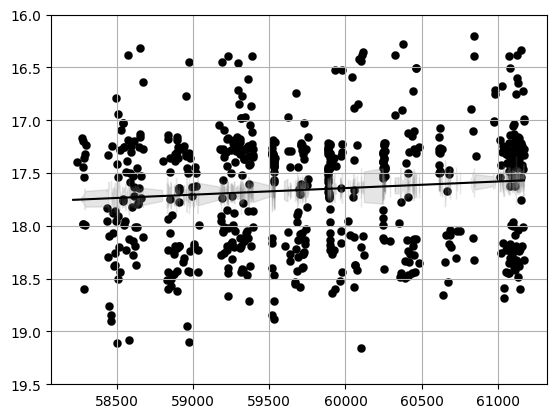

In [92]:
locus1 = DevKitLocus.model_validate(locus_dict)
lightcurve = locus1.lightcurve()

fit = fitting.LinearLSQFitter(calc_uncertainties=True)
line_init = models.Linear1D()
err = lightcurve["ant_magerr"] # this isn't the right way to do this,,,,,,
long_term_lightcurve = fit(line_init, lightcurve["ant_mjd"], lightcurve["ant_mag"])

plt.scatter(lightcurve["ant_mjd"], lightcurve["ant_mag"], color='k', lw=0.1)
plt.plot(lightcurve["ant_mjd"], long_term_lightcurve(lightcurve["ant_mjd"]), 'k')
plt.fill_between(lightcurve["ant_mjd"], long_term_lightcurve(lightcurve["ant_mjd"])-std, long_term_lightcurve(lightcurve["ant_mjd"])+std, color='grey', alpha=0.2)
plt.ylim(19.5, 16)
plt.grid()

Model: Linear1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
            slope              intercept     
    ---------------------- ------------------
    -4.054915993369661e-05 19.858765220355142


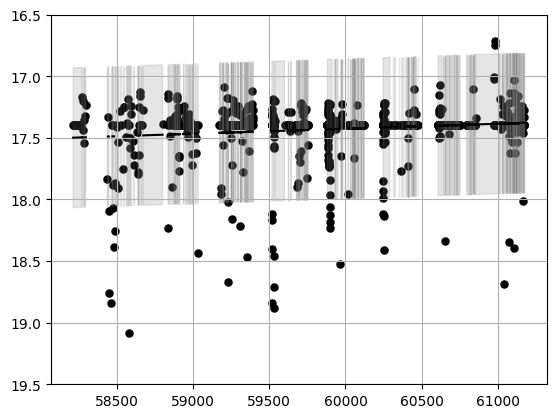

In [91]:
mask = np.ma.masked_where(lightcurve["ant_passband"] != 'R', lightcurve)

std_m = np.std(mask["ant_mag"])
var_m = np.var (mask["ant_mag"])
long_term_lightcurve = fit(line_init, mask["ant_mjd"], mask["ant_mag"])

plt.plot(mask["ant_mjd"], long_term_lightcurve(mask["ant_mjd"]), 'k-')
plt.scatter(mask["ant_mjd"], mask["ant_mag"], color='k', lw=0.1)
plt.fill_between(mask["ant_mjd"], long_term_lightcurve(mask["ant_mjd"])-std, long_term_lightcurve(mask["ant_mjd"])+std, color='grey', alpha=0.2)
plt.ylim(19.5, 16.5)
plt.grid()

print(long_term_lightcurve)

In [10]:
# directly from the Anomalytransientdmdt antares filter
def get_detections(photometry, band):
    """Extract clean light curve in given band from locus photometry"""
    from astropy.table import MaskedColumn

    band_lc = photometry[photometry["ant_passband"] == band]
    idx = ~MaskedColumn(band_lc["ant_mag"]).mask
    detections = remove_simultaneous_alerts(band_lc[idx])
    return detections

def remove_simultaneous_alerts(table):
    """Remove alert duplicates"""
    import numpy as np

    dt = np.diff(table["ant_mjd"], append=np.inf)
    return table[dt != 0]

In [34]:
from astropy.modeling import models, fitting

fit = fitting.LinearLSQFitter(calc_uncertainties=True)
line_init = models.Linear1D()


long_term_lightcurve = fit(line_init, photometry["ant_mag"], photometry["ant_mjd"])
# make a function that determines if the object is highly variable
# building with the idea that the most recent observation was last night
slope_change_threshold = 1 # mag /mjd
time_pass_threshold = 20 # days
def get_ext_variables(photometry):
    # what i want to do:
    long_term_lightcurve = fit(line_init, photometry["ant_mag"], photometry["ant_mjd"])
    
    mjd_now = photometry[0]["ant_mjd"]
    # if (mjd_now - photometry[i]["ant_mjd"]) < time_pass_threshold:
        fitted_line = fit(line_init, photometry[0:i]["ant_mag"], photometry[0:i]["ant_mjd"])
        slope = fitted_line.slope
        if abs(slope) < slope_change_threshold:
            # no High variability
            i +=1
        else:
            return photometry
    elif (mjd_now - photometry[i]["ant_mjd"]) > time_pass_threshold:
        # no Recent variability
        return 0

IndentationError: unexpected indent (1679306081.py, line 18)

In [14]:
class HighMagChange(BaseFilter):
    """
    This filter finds locus with recent extreme brightness variability.
    The thresholds used are r_slope > # within # days.

    Current assumptions:
    - real time alert ingestion
    - slope
    - number of days for this slope detection
    - band (r)
    """

    SLACK_CHANNEL = "#fliter-extreme-recent-variables"
    
    TRIGGERING_SURVEY = "lsst"
    REQUIRED_ALERT_PROPERTIES = [
        "lsst_diaSource_diaObjectId",
        "ant_mjd",
        "ant_mag",
        "ant_maglim",
        "ant_magerr",
        "ant_passband"
    ]
    OUTPUT_LOCUS_TAGS = [
        {
            "name": "extreme_transient_candidate_v1",
            "description": "Locus with alert(s) having high change in mag.",
        },
    ]

    band = "r"
    min_obs_count = 4
    faint_mag_threshold = 30

    # def setup(self):
        # idk if i need this bit,,,,,,,,,
    
    def _run(self, locus):
        import numpy as np
        from astropy.time import Time
        
        # get clean lightcurve in one band, with the TimeSeries being in reverse order (so newest is first)
        # for now, im focusing on the r band
        lightcurve = locus.lightcurve(self.TRIGGERING_SURVEY)
        detections = get_detections(lightcurve, self.band)
        detections.sort("ant_mjd", reverse=True)
        # print(detections[0]["ant_mag"])

        if detections[0]["ant_mag"] > self.faint_mag_threshold:
            print('too dim to collect spectra')
            return
        
        if len(detections) < self.min_obs_count:
            print('not enough data')
            return 

        # det if the lightcurve shows high enough variability
        variables = get_ext_variables(detections)

        if variables == 0:
            # no recent, high variability seen in the lightcurve
            print("no recent, high variability seen in the lightcurve")
            return 
        else:
            return variables # this is temporary
            # locus.tag("extreme_recent_variable")
            
        # The threshold is dependent on the band that is being imaged.
        # These thresholds should flag ~2-3% of alerts.
        # snr_threshold = {
        #     1: 50.0,
        #     2: 55.0,
        # }  # Only have thresholds for passbands ztf_fid 1 and 2, i.e., g and R passbands.

        # Determine the passband of the most recent alert at this locus.
        # fid = locus.alert.properties["ztf_fid"]  # current alert passband
        # if fid not in snr_threshold.keys():
        #     # print(f"ZTF passband id {fid} is not supported by this filter.")
        #     return  # Do nothing.

        # # Calculate the SNR of the latest alert
        # sigmapsf = locus.alert.properties["ztf_sigmapsf"]  # current alert sigma
        # threshold = snr_threshold[fid]
        # alert_snr = 1.0 / sigmapsf

        # alert_id = locus.alert.alert_id  # current alert_id
        # ztf_object_id = locus.properties['ztf_object_id']  # ZTF Object ID

        # Tag this locus if the latest alert meets our SNR criteria
        # if alert_snr > threshold:
        #     # print('High SNR detected')
        #     locus.tag("high_snr")

In [15]:
here = HighMagChange()
here.run(locus1)

FilterReturn(status='Skipped', exception_name=None, exception_message=None, traceback=None)

ques:
1. how does this work if youre trying to look at multiple loci? does each loci run thru the filter individually, or are they sent in as a packet?

In [75]:
loci = ["ANT2020h3zzw", "ANT2024lrwe5t0dhfyk", "ANT2020mbdmm", "ANT2020gnbyk", "ANT2020gjbf6"]

for locus in loci:
    client_locus = search.get_by_id(locus)
    locus_dict = client_locus.to_devkit()
    valid_locus = DevKitLocus.model_validate(locus_dict)
    here = HighMagChange()
    result = here.run(valid_locus)
    print(result)

AntaresException: {'errors': [{'detail': 'A server-side problem occured.', 'status': 500, 'title': 'Internal Server Error'}]}

In [61]:
result

FilterReturn(status='Skipped', exception_name=None, exception_message=None, traceback=None)

next step: using more data to test if my filter would work against an active alert stream. use the [getting data](https://nsf-noirlab.gitlab.io/csdc/antares/devkit/learn/getting-data/) page to figure it out

In [13]:
from astropy.time import Time

In [64]:
t_now = Time.now()
print(t_now.mjd)
day_mjd = 61120

61165.70786260154


In [93]:
query = {
    "query": {
        "bool": {
            "filter": [
                {
                    "range": {
                        "properties.newest_alert_observation_time": {
                            "gte": day_mjd,
                            "lte": day_mjd+1,
                        }
                    } 
                }
             ]
        }
    }
}

query1 = {
    "query": {
        "bool": {
            "must": [
                {
                    "range": {
                        "properties.newest_alert_observation_time": {
                            "gte": day_mjd,
                            "lte": day_mjd+1,
                        }
                    },
                    "fuzzy": {
                        "properties.survey.lsst.dia_object_id": {
                            "value": "1"
                        }
                    },
                    "match": {
                        "tag": "high_amplitude_transient_candidate"
                }
             ]
        }
    }
}


SyntaxError: closing parenthesis ']' does not match opening parenthesis '{' on line 22 (823556835.py, line 37)

In [74]:
y = list(search.search(query))
y

KeyboardInterrupt: 

In [54]:
x = list(search.search(query))
x

 ...]

In [35]:
tags = search.get_available_tags()
# tags = search.get_catalog_samples(10)
print(tags)

['refitt_newsources_snrcut', 'lc_feature_extractor', 'in_LSSTDDF', 'sso_candidates', 'young_extragalactic_candidate', 'sso_confirmed', 'siena_mag_coord_cut', 'dimmers', 'high_flux_ratio_wrt_nn', 'extragalactic', 'high_snr', 'NUTTelA_TAO', 'matheson_extreme_vpdf', 'nuclear_transient', 'high_amplitude_variable_star_candidate', 'desoto_classified', 'in_shadow_virgo', 'iso_forest_anomaly_detection', 'high_amplitude_transient_candidate', 'recent_reddening', 'in_m31', 'nova_test', 'blue_transient', 'LAISS_RFC_AD_filter', 'desi_target', 'superphot_plus_classified', 'lsst_scimma_quality_transient', 'dwarf_nova_outburst', 'young_rubin_transients', 'imhb_candidate', 'SN_candies', 'microlensing_candidate', 'soraisam_sublum', 'ECL_blue_transient_candidate']


In [69]:
# for locus in x[0]:
#     # client_locus = search.get_by_id(locus)
#     locus_dict = locus.to_devkit()
#     valid_locus = DevKitLocus.model_validate(locus_dict)
#     here = HighMagChange()
#     result1 = here.run(valid_locus)
#     if result1 != result:
#         print(result1)


locus_dict = x[0].to_devkit()
valid_locus = DevKitLocus.model_validate(locus_dict)
here = HighMagChange()
result1 = here.run(valid_locus)
print(result1)

status='Skipped' exception_name=None exception_message=None traceback=None
